In [2]:
import json
import os
import pickle
import warnings
from dataclasses import dataclass, asdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from scipy import stats as sp_stats
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams["figure.dpi"] = 100

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {DEVICE}")

Using: cuda


In [ ]:
@dataclass
class Settings:
    #data
    data_path    : str   = "/kaggle/input/datasets/adityakansara23/imputed/df_complete_clean.pkl"
    devices      : tuple = (1, 2, 3, 4)
    gap_min_sec  : float = 60.0           
    gap_max_sec  : float = 14400.0        
    work_start_h : int   = 9              
    work_end_h   : int   = 17             

    # ── Sequence lengths ──────────────────────────────────────────────────
    context_len  : int   = 50
    seq_len      : int   = 50   
    stride       : int   = 5    

    # ── Model ─────────────────────────────────────────────────────────────
    noise_dim    : int   = 64   
    hidden_size  : int   = 128  
    ctx_size     : int   = 64   
    num_layers   : int   = 2 
    dropout      : float = 0.2

    # ── Training ──────────────────────────────────────────────────────────
    epochs       : int   = 300     #500
    batch_size   : int   = 64      #64
    lr_gen       : float = 2e-4   
    lr_dis       : float = 1e-4    
    clip_grad    : float = 1.0     
    label_smooth : float = 0.1   
    lr_min       : float = 1e-5    

    # ── Misc ──────────────────────────────────────────────────────────────
    log_every    : int   = 50
    blend_steps  : int   = 5     
    seed         : int   = 42
    save_dir     : str   = "outputs_gan"

S = Settings()
os.makedirs(S.save_dir, exist_ok=True)
torch.manual_seed(S.seed)
np.random.seed(S.seed)
print("Settings ready.")

Settings ready.


In [ ]:
#condition to the generator
COND_FEATURES = [
    "Latitude", "Longitude",  
    "speed_kmh", "COG",        
]

# network quality metrics
TARGET_FEATURES = [
    # Signal quality
    "PCell_RSRP_max", "PCell_RSRQ_max", "PCell_RSSI_max",
    "PCell_SNR_1", "PCell_SNR_2",
    # Resource blocks and throughput
    "PCell_Downlink_Num_RBs", "PCell_Downlink_TB_Size", "PCell_Downlink_Average_MCS",
    "PCell_Uplink_Num_RBs",   "PCell_Uplink_TB_Size",   "PCell_Uplink_Tx_Power_(dBm)",
    # Frequency and bandwidth
    "PCell_Downlink_frequency", "PCell_Downlink_bandwidth_MHz",
    "PCell_Uplink_bandwidth_MHz", "PCell_Band_Indicator", "PCell_freq_MHz",
    # Application-level quality
    "ping_ms", "datarate", "jitter",
]

EXTERNAL_FEATURES = [
    "precipIntensity", "precipProbability", "temperature",
    "humidity", "windSpeed", "Traffic Jam Factor", "Traffic Distance",
]


ROBUST_FEATURES = ["jitter", "Traffic Distance", "Traffic Jam Factor"]


ALL_MODEL_FEATURES = COND_FEATURES + TARGET_FEATURES
N_TEMPORAL = 5
N_FEATURES = len(ALL_MODEL_FEATURES) + N_TEMPORAL

print(f"Conditioning features : {len(COND_FEATURES)}")
print(f"Target features       : {len(TARGET_FEATURES)}")
print(f"External features     : {len(EXTERNAL_FEATURES)}  (carry-forward, not generated)")
print(f"Temporal channels     : {N_TEMPORAL}")
print(f"Total LSTM input width: {N_FEATURES}")

Conditioning features : 4
Target features       : 19
External features     : 7  (carry-forward, not generated)
Temporal channels     : 5
Total LSTM input width: 28


In [ ]:
print(f"Loading {S.data_path} ...")
with open(S.data_path, "rb") as f:
    raw = pickle.load(f)

print(f"Full dataset: {len(raw):,} rows x {raw.shape[1]} columns")


frames = []
for d in S.devices:
    col = f"device_pc{d}"
    sub = raw[raw[col] == 1].copy()
    sub["device"] = d
    frames.append(sub)

df = pd.concat(frames).sort_values(["device", "timestamp"]).reset_index(drop=True)
print(f"\nDevice breakdown:")
for d in S.devices:
    n = (df["device"] == d).sum()
    op = df[df["device"] == d]["operator"].iloc[0]
    print(f"  device_pc{d}: {n:>6,} rows  operator={op}")
print(f"\nTotal rows: {len(df):,}")

Loading /kaggle/input/datasets/adityakansara23/imputed/df_complete_clean.pkl ...
Full dataset: 204,942 rows x 50 columns

Device breakdown:
  device_pc1: 59,519 rows  operator=0
  device_pc2: 42,879 rows  operator=1
  device_pc3: 59,723 rows  operator=1
  device_pc4: 42,821 rows  operator=0

Total rows: 204,942


In [ ]:
def find_segments_and_gaps(device_df, device_id, S):

    device_df = device_df.copy()
    device_df["delta_sec"] = device_df["timestamp"].diff().dt.total_seconds().fillna(0)
    device_df["segment_id"] = (device_df["delta_sec"] > S.gap_min_sec).cumsum()

    gaps = []
    gap_rows = device_df[device_df["delta_sec"] > S.gap_min_sec]

    for idx in gap_rows.index:
        prev      = device_df.loc[idx - 1]
        curr      = device_df.loc[idx]
        gap_sec   = curr["delta_sec"]
        h_start   = prev["timestamp"].hour
        h_end     = curr["timestamp"].hour

        # Skip overnight gaps and gaps outside working hours
        if gap_sec >= S.gap_max_sec:
            continue
        if h_start < S.work_start_h or h_end > S.work_end_h:
            continue

        tz = prev["timestamp"].tzinfo
        gaps.append({
            "device"       : device_id,
            "gap_start"    : prev["timestamp"],
            "gap_end"      : curr["timestamp"],
            "n_steps"      : int(gap_sec),
            "seg_before"   : int(prev["segment_id"]),
            "seg_after"    : int(curr["segment_id"]),
            
            "fill_ts"      : pd.date_range(
                                 start   = prev["timestamp"] + pd.Timedelta(seconds=1),
                                 periods = int(gap_sec),
                                 freq    = "1s",
                                 tz      = tz),
            
            "ctx_idx"      : device_df[
                                 device_df["segment_id"] == int(prev["segment_id"])
                             ].index[-S.context_len :],
            
            "after_idx"    : device_df[
                                 device_df["segment_id"] == int(curr["segment_id"])
                             ].index[: S.context_len],
        })

    return device_df, gaps


# Run gap detection on all devices
all_device_dfs = {}
all_gaps       = []

for d in S.devices:
    dev_df = df[df["device"] == d].sort_values("timestamp").reset_index(drop=True)
    dev_df, gaps = find_segments_and_gaps(dev_df, d, S)
    all_device_dfs[d] = dev_df
    all_gaps.extend(gaps)

print(f"Total fillable gaps across all devices: {len(all_gaps)}")
print()
print(f"{'Device':<10} {'Start':>22} {'End':>22} {'Steps':>8}")
print("-" * 68)
for g in all_gaps:
    print(f"  pc{g['device']}     {str(g['gap_start'])[:22]:>22}  "
          f"{str(g['gap_end'])[:22]:>22}  {g['n_steps']:>8,}")

Total fillable gaps across all devices: 50

Device                      Start                    End    Steps
--------------------------------------------------------------------
  pc1     2021-06-22 11:06:00+02  2021-06-22 11:26:15+02     1,215
  pc1     2021-06-22 12:23:59+02  2021-06-22 14:33:00+02     7,741
  pc1     2021-06-22 15:44:59+02  2021-06-22 15:56:30+02       691
  pc1     2021-06-22 16:26:04+02  2021-06-22 16:33:46+02       462
  pc1     2021-06-22 17:16:59+02  2021-06-22 17:24:58+02       479
  pc1     2021-06-23 10:21:59+02  2021-06-23 10:34:41+02       762
  pc1     2021-06-23 11:27:59+02  2021-06-23 11:30:09+02       130
  pc1     2021-06-23 12:15:59+02  2021-06-23 13:50:38+02     5,679
  pc1     2021-06-23 14:48:59+02  2021-06-23 14:54:56+02       357
  pc1     2021-06-23 15:54:59+02  2021-06-23 16:07:16+02       737
  pc1     2021-06-24 09:47:59+02  2021-06-24 09:54:00+02       361
  pc1     2021-06-24 10:43:59+02  2021-06-24 11:06:33+02     1,354
  pc1     2021-06

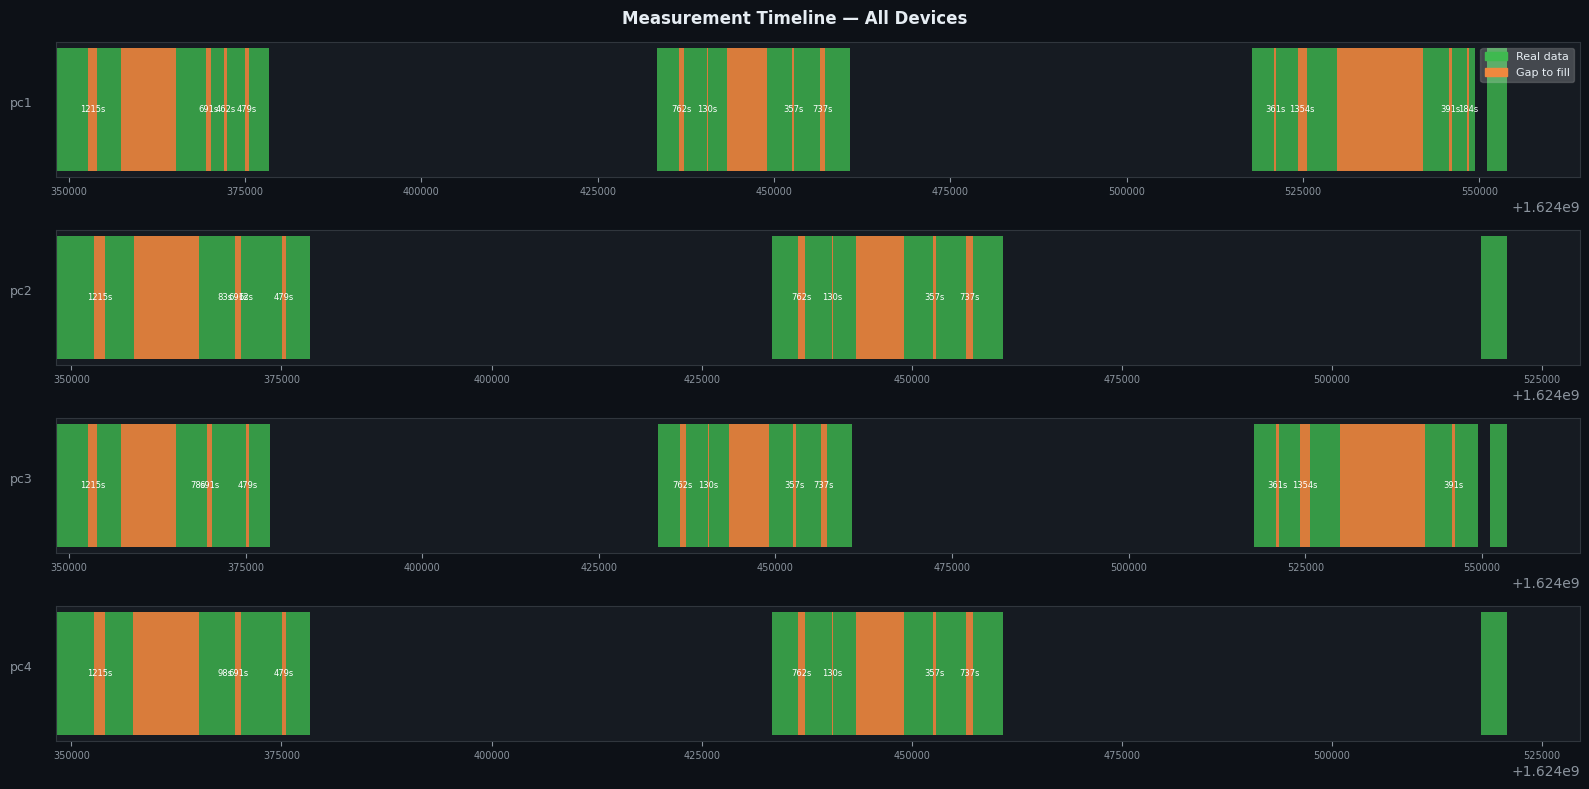

In [7]:
# Timeline plot — one row per device
fig, axes = plt.subplots(len(S.devices), 1,
                         figsize=(16, 2 * len(S.devices)), facecolor="#0d1117")
if len(S.devices) == 1:
    axes = [axes]

from matplotlib.patches import Patch

for ax, d in zip(axes, S.devices):
    dev_df = all_device_dfs[d]
    ax.set_facecolor("#161b22")

    # Real segments — green
    for sid in dev_df["segment_id"].unique():
        seg = dev_df[dev_df["segment_id"] == sid]
        t0  = seg["timestamp"].iloc[0].timestamp()
        t1  = seg["timestamp"].iloc[-1].timestamp()
        ax.barh(0, t1 - t0, left=t0, height=0.5, color="#3fb950", alpha=0.8)

    # Fillable gaps — orange
    for g in [g for g in all_gaps if g["device"] == d]:
        t0 = g["gap_start"].timestamp()
        ax.barh(0, g["n_steps"], left=t0, height=0.5, color="#f0883e", alpha=0.9)
        if g["n_steps"] < 5000:
            ax.text(t0 + g["n_steps"]/2, 0, f"{g['n_steps']}s",
                    ha="center", va="center", fontsize=6, color="white")

    ax.set_yticks([])
    ax.set_ylabel(f"pc{d}", color="#8b949e", fontsize=9, rotation=0, labelpad=25)
    for sp in ax.spines.values(): sp.set_edgecolor("#30363d")
    ax.tick_params(colors="#8b949e", labelsize=7)

axes[0].legend(handles=[Patch(color="#3fb950", label="Real data"),
                         Patch(color="#f0883e", label="Gap to fill")],
               framealpha=0.2, labelcolor="#e6edf3", fontsize=8, loc="upper right")
fig.suptitle("Measurement Timeline — All Devices", color="#e6edf3",
             fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

In [ ]:
class Scaler:


    def __init__(self, feature_cols, robust_cols):
        self.feature_cols = feature_cols
        self.robust_idx   = [feature_cols.index(f) for f in robust_cols
                             if f in feature_cols]
        self.normal_idx   = [i for i in range(len(feature_cols))
                             if i not in self.robust_idx]
        self.rob = RobustScaler()
        self.rmm = MinMaxScaler((-1, 1))
        self.mm  = MinMaxScaler((-1, 1))

    def fit_transform(self, X):
        out = np.empty(X.shape, dtype=np.float32)
        if self.robust_idx:
            out[:, self.robust_idx] = self.rmm.fit_transform(
                                          self.rob.fit_transform(X[:, self.robust_idx]))
        if self.normal_idx:
            out[:, self.normal_idx] = self.mm.fit_transform(X[:, self.normal_idx])
        return out

    def transform(self, X):
        out = np.empty(X.shape, dtype=np.float32)
        if self.robust_idx:
            out[:, self.robust_idx] = self.rmm.transform(
                                          self.rob.transform(X[:, self.robust_idx]))
        if self.normal_idx:
            out[:, self.normal_idx] = self.mm.transform(X[:, self.normal_idx])
        return out

    def inverse_transform(self, X):
        out = np.empty(X.shape, dtype=np.float32)
        if self.robust_idx:
            out[:, self.robust_idx] = self.rob.inverse_transform(
                                          self.rmm.inverse_transform(X[:, self.robust_idx]))
        if self.normal_idx:
            out[:, self.normal_idx] = self.mm.inverse_transform(X[:, self.normal_idx])
        return out


# Fit scaler on all devices combined
X_all = pd.concat([all_device_dfs[d] for d in S.devices])[ALL_MODEL_FEATURES].values.astype(np.float32)
scaler = Scaler(ALL_MODEL_FEATURES, ROBUST_FEATURES)
_ = scaler.fit_transform(X_all)

print("Scaler fitted on all devices.")
print(f"  Normal group  : {len(scaler.normal_idx)} features")
print(f"  Robust group  : {len(scaler.robust_idx)} features  "
      f"({[ALL_MODEL_FEATURES[i] for i in scaler.robust_idx]})")

Scaler fitted on all devices.
  Normal group  : 22 features
  Robust group  : 1 features  (['jitter'])


In [ ]:
def make_time_features(timestamps, segment_ids):
    
    ts = pd.Series(timestamps)

    # Time of day — projected onto unit circle
    sod     = (ts.dt.hour * 3600 + ts.dt.minute * 60 + ts.dt.second).values
    sin_hr  = np.sin(2 * np.pi * sod / 86400).astype(np.float32)
    cos_hr  = np.cos(2 * np.pi * sod / 86400).astype(np.float32)

    # Day of week — projected onto unit circle
    dow     = ts.dt.dayofweek.values.astype(float)
    sin_dow = np.sin(2 * np.pi * dow / 7).astype(np.float32)
    cos_dow = np.cos(2 * np.pi * dow / 7).astype(np.float32)

    # Position within each segment — 0 = start, 1 = end → rescaled to [-1, 1]
    elapsed = np.zeros(len(ts), dtype=np.float32)
    for sid in np.unique(segment_ids):
        mask = segment_ids == sid
        n    = mask.sum()
        elapsed[mask] = np.linspace(-1, 1, n, dtype=np.float32)

    return np.stack([sin_hr, cos_hr, sin_dow, cos_dow, elapsed], axis=1)


def make_time_features_for_gap(fill_timestamps, n_steps):
    ts      = pd.DatetimeIndex(fill_timestamps)
    sod     = (ts.hour * 3600 + ts.minute * ts.second).values
    sin_hr  = np.sin(2 * np.pi * sod / 86400).astype(np.float32)
    cos_hr  = np.cos(2 * np.pi * sod / 86400).astype(np.float32)
    dow     = ts.dayofweek.astype(float).values
    sin_dow = np.sin(2 * np.pi * dow / 7).astype(np.float32)
    cos_dow = np.cos(2 * np.pi * dow / 7).astype(np.float32)
    elapsed = np.linspace(0.8, 1.2, n_steps, dtype=np.float32).clip(-1, 1)
    return np.stack([sin_hr, cos_hr, sin_dow, cos_dow, elapsed], axis=1)


print("Temporal feature functions defined.")

Temporal feature functions defined.


In [ ]:

device_X = {}

for d in S.devices:
    dev_df   = all_device_dfs[d]
    X_base   = dev_df[ALL_MODEL_FEATURES].values.astype(np.float32)
    X_scaled = np.clip(scaler.transform(X_base), -1.0, 1.0)
    X_time   = make_time_features(dev_df["timestamp"].values,
                                   dev_df["segment_id"].values)
    device_X[d] = np.concatenate([X_scaled, X_time], axis=1).astype(np.float32)
    print(f"  device_pc{d}: {device_X[d].shape}  "
          f"range=[{device_X[d].min():.3f}, {device_X[d].max():.3f}]")

print(f"\nTotal feature width per timestep: {N_FEATURES}  "
      f"({len(ALL_MODEL_FEATURES)} features + {N_TEMPORAL} time channels)")

  device_pc1: (59519, 28)  range=[-1.000, 1.000]
  device_pc2: (42879, 28)  range=[-1.000, 1.000]
  device_pc3: (59723, 28)  range=[-1.000, 1.000]
  device_pc4: (42821, 28)  range=[-1.000, 1.000]

Total feature width per timestep: 28  (23 features + 5 time channels)


In [11]:
context_list = []
target_list  = []
C, T, St     = S.context_len, S.seq_len, S.stride

for d in S.devices:
    dev_df = all_device_dfs[d]
    X      = device_X[d]

    for seg_id in dev_df["segment_id"].unique():
        mask  = dev_df["segment_id"].values == seg_id
        X_seg = X[mask]
        n     = len(X_seg)

        # Need at least C rows of context + T rows of target
        for i in range(C, n - T + 1, St):
            context_list.append(X_seg[i - C : i])   # (C, N_FEATURES)
            target_list.append( X_seg[i     : i + T]) # (T, N_FEATURES)

contexts = np.stack(context_list).astype(np.float32)  # (N_pairs, C, F)
targets  = np.stack(target_list).astype(np.float32)   # (N_pairs, T, F)

print(f"Training pairs : {len(contexts):,}")
print(f"Context shape  : {contexts.shape}")
print(f"Target  shape  : {targets.shape}")

Training pairs : 39,749
Context shape  : (39749, 50, 28)
Target  shape  : (39749, 50, 28)


In [12]:
class ContextEncoder(nn.Module):
    """Reads real context → single summary vector."""

    def __init__(self, n_features, ctx_size, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(n_features, ctx_size, num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.)
        self.norm = nn.LayerNorm(ctx_size)

    def forward(self, context):
        # context: (batch, context_len, n_features)
        # output : (batch, ctx_size)
        _, (h_last, _) = self.lstm(context)
        return self.norm(h_last[-1])   # take top layer's final hidden state


class Generator(nn.Module):
    """Random noise + context → synthetic time series."""

    def __init__(self, noise_dim, ctx_size, hidden_size, num_layers,
                 n_features, dropout):
        super().__init__()
        self.lstm = nn.LSTM(noise_dim + ctx_size, hidden_size, num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.)
        self.norm = nn.LayerNorm(hidden_size)
        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_size // 2, n_features),
            nn.Tanh(),   # output in [-1, 1] to match scaler range
        )

    def forward(self, noise, ctx_vec):
        # noise  : (batch, seq_len, noise_dim)
        # ctx_vec: (batch, ctx_size)
        ctx_repeated = ctx_vec.unsqueeze(1).expand(-1, noise.size(1), -1)
        lstm_input   = torch.cat([noise, ctx_repeated], dim=-1)
        out, _       = self.lstm(lstm_input)
        return self.head(self.norm(out))   # (batch, seq_len, n_features)


class Discriminator(nn.Module):
    """[Context + fill] → real or fake."""

    def __init__(self, n_features, hidden_size, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden_size, num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.)
        self.norm = nn.LayerNorm(hidden_size)
        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(hidden_size // 2, 1),
            # No sigmoid here — BCEWithLogitsLoss applies it internally
        )

    def forward(self, sequence):
        # sequence: (batch, context_len + seq_len, n_features)
        _, (h_last, _) = self.lstm(sequence)
        return self.head(self.norm(h_last[-1]))   # (batch, 1)


# Build models
Enc = ContextEncoder(N_FEATURES, S.ctx_size, S.num_layers, S.dropout).to(DEVICE)
G   = Generator(S.noise_dim, S.ctx_size, S.hidden_size,
                S.num_layers, N_FEATURES, S.dropout).to(DEVICE)
D   = Discriminator(N_FEATURES, S.hidden_size, S.num_layers, S.dropout).to(DEVICE)

n_enc = sum(p.numel() for p in Enc.parameters())
n_g   = sum(p.numel() for p in G.parameters())
n_d   = sum(p.numel() for p in D.parameters())
print(f"ContextEncoder : {n_enc:>10,} parameters")
print(f"Generator      : {n_g:>10,} parameters")
print(f"Discriminator  : {n_d:>10,} parameters")
print(f"Total          : {n_enc+n_g+n_d:>10,} parameters")

# Quick shape check
_ctx   = torch.randn(4, S.context_len, N_FEATURES, device=DEVICE)
_z     = torch.randn(4, S.seq_len, S.noise_dim, device=DEVICE)
_h     = Enc(_ctx)
_fake  = G(_z, _h)
_logit = D(torch.cat([_ctx, _fake], dim=1))
print(f"\nShape check:")
print(f"  context {tuple(_ctx.shape)} → h_ctx {tuple(_h.shape)}")
print(f"  noise   {tuple(_z.shape)} → fake  {tuple(_fake.shape)}")
print(f"  [ctx+fake] {tuple(torch.cat([_ctx,_fake],dim=1).shape)} → logit {tuple(_logit.shape)}  ✓")
del _ctx, _z, _h, _fake, _logit

ContextEncoder :     57,472 parameters
Generator      :    274,524 parameters
Discriminator  :    221,569 parameters
Total          :    553,565 parameters

Shape check:
  context (4, 50, 28) → h_ctx (4, 64)
  noise   (4, 50, 64) → fake  (4, 50, 28)
  [ctx+fake] (4, 100, 28) → logit (4, 1)  ✓


In [13]:
def make_noise(batch, seq_len, noise_dim, device):
    return torch.randn(batch, seq_len, noise_dim, device=device)


# DataLoader
dataset = TensorDataset(torch.from_numpy(contexts), torch.from_numpy(targets))
loader  = DataLoader(dataset, batch_size=S.batch_size,
                     shuffle=True, drop_last=True, num_workers=0)

# Optimisers — Encoder and Generator share one optimiser
opt_EG = optim.Adam(list(Enc.parameters()) + list(G.parameters()),
                    lr=S.lr_gen, betas=(0.5, 0.999))
opt_D  = optim.Adam(D.parameters(), lr=S.lr_dis, betas=(0.5, 0.999))

# Cosine annealing — LR decays smoothly but never hits 0 (eta_min fix)
sched_EG = optim.lr_scheduler.CosineAnnealingLR(opt_EG, S.epochs, eta_min=S.lr_min)
sched_D  = optim.lr_scheduler.CosineAnnealingLR(opt_D,  S.epochs, eta_min=S.lr_min)

loss_fn = nn.BCEWithLogitsLoss()

print(f"Training {S.epochs} epochs | {len(contexts):,} pairs | "
      f"batch={S.batch_size} | device={DEVICE}\n")

d_history, g_history = [], []

for epoch in range(1, S.epochs + 1):
    Enc.train(); G.train(); D.train()
    d_buf, g_buf = [], []

    for ctx_batch, real_target in loader:
        B           = ctx_batch.size(0)
        ctx_batch   = ctx_batch.to(DEVICE)
        real_target = real_target.to(DEVICE)
        real_seq    = torch.cat([ctx_batch, real_target], dim=1)

        # ── Train Discriminator ───────────────────────────────────────
        opt_D.zero_grad()

        # Real pair: context + real continuation → should output 1
        real_labels = torch.full((B, 1), 1.0 - S.label_smooth, device=DEVICE)
        d_real      = loss_fn(D(real_seq), real_labels)

        # Fake pair: context + generated → should output 0
        with torch.no_grad():
            fake = G(make_noise(B, S.seq_len, S.noise_dim, DEVICE), Enc(ctx_batch))
        fake_labels = torch.zeros(B, 1, device=DEVICE)
        d_fake      = loss_fn(D(torch.cat([ctx_batch, fake], dim=1)), fake_labels)

        d_loss = d_real + d_fake
        d_loss.backward()
        nn.utils.clip_grad_norm_(D.parameters(), S.clip_grad)
        opt_D.step()

        # ── Train Encoder + Generator ─────────────────────────────────
        opt_EG.zero_grad()

        fake   = G(make_noise(B, S.seq_len, S.noise_dim, DEVICE), Enc(ctx_batch))
        # Generator wants Discriminator to output 1 for its fakes
        g_loss = loss_fn(D(torch.cat([ctx_batch, fake], dim=1)),
                         torch.ones(B, 1, device=DEVICE))
        g_loss.backward()
        nn.utils.clip_grad_norm_(
            list(Enc.parameters()) + list(G.parameters()), S.clip_grad)
        opt_EG.step()

        d_buf.append(d_loss.item())
        g_buf.append(g_loss.item())

    sched_EG.step(); sched_D.step()
    d_history.append(np.mean(d_buf))
    g_history.append(np.mean(g_buf))

    if epoch % S.log_every == 0 or epoch == 1:
        print(f"  Epoch [{epoch:4d}/{S.epochs}]  "
              f"D: {d_history[-1]:.4f}  G: {g_history[-1]:.4f}  "
              f"lr: {sched_EG.get_last_lr()[0]:.2e}  "
              f"(target: both → {np.log(2):.3f})")

print("\nDone.")

Training 300 epochs | 39,749 pairs | batch=64 | device=cuda

  Epoch [   1/300]  D: 1.3713  G: 0.8583  lr: 2.00e-04  (target: both → 0.693)
  Epoch [  50/300]  D: 1.3729  G: 0.8100  lr: 1.87e-04  (target: both → 0.693)
  Epoch [ 100/300]  D: 1.3720  G: 0.8075  lr: 1.53e-04  (target: both → 0.693)
  Epoch [ 150/300]  D: 1.3718  G: 0.8094  lr: 1.05e-04  (target: both → 0.693)
  Epoch [ 200/300]  D: 1.3695  G: 0.8104  lr: 5.75e-05  (target: both → 0.693)
  Epoch [ 250/300]  D: 1.2790  G: 0.9643  lr: 2.27e-05  (target: both → 0.693)
  Epoch [ 300/300]  D: 1.0884  G: 1.3590  lr: 1.00e-05  (target: both → 0.693)

Done.


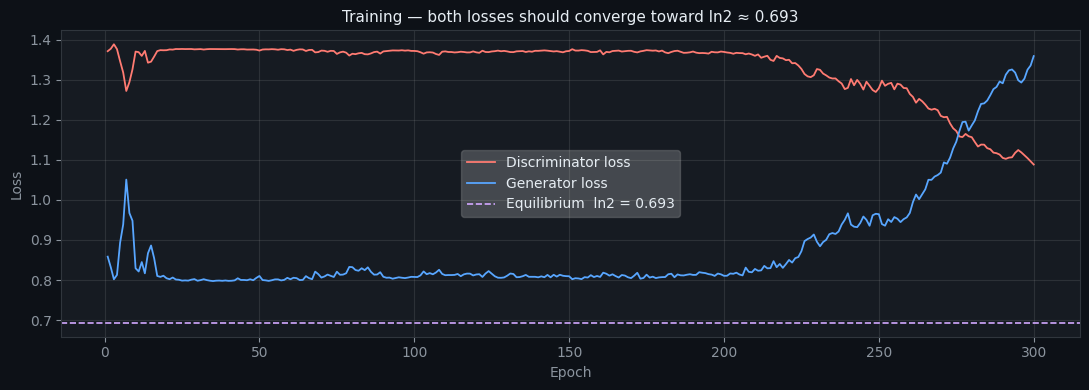

Final D loss : 1.0884  (target: ~0.693)
Final G loss : 1.3590  (target: ~0.693)
Gap to equil : D=0.3952  G=0.6659


In [14]:
fig, ax = plt.subplots(figsize=(11, 4), facecolor="#0d1117")
ax.set_facecolor("#161b22")
e = range(1, len(d_history) + 1)
ax.plot(e, d_history, color="#ff7b72", lw=1.3, label="Discriminator loss")
ax.plot(e, g_history, color="#58a6ff", lw=1.3, label="Generator loss")
ax.axhline(np.log(2), color="#d2a8ff", lw=1.2, ls="--",
           label=f"Equilibrium  ln2 = {np.log(2):.3f}")
ax.set_xlabel("Epoch", color="#8b949e")
ax.set_ylabel("Loss",  color="#8b949e")
ax.set_title("Training — both losses should converge toward ln2 ≈ 0.693",
             color="#e6edf3", fontsize=11)
ax.legend(framealpha=0.2, labelcolor="#e6edf3")
ax.grid(alpha=0.15)
ax.tick_params(colors="#8b949e")
for sp in ax.spines.values(): sp.set_edgecolor("#30363d")
plt.tight_layout(); plt.show()

print(f"Final D loss : {d_history[-1]:.4f}  (target: ~{np.log(2):.3f})")
print(f"Final G loss : {g_history[-1]:.4f}  (target: ~{np.log(2):.3f})")
print(f"Gap to equil : D={abs(d_history[-1]-np.log(2)):.4f}  "
      f"G={abs(g_history[-1]-np.log(2)):.4f}")

In [15]:
def fill_gap(gap, device_X_dict, all_device_dfs, S, Enc, G, DEVICE):
    """
    Generate synthetic data to fill one gap.
    Returns np.ndarray of shape (n_steps, N_FEATURES) in scaled space.
    """
    Enc.eval(); G.eval()
    C, T = S.context_len, S.seq_len
    d    = gap["device"]

    # Get the last C real rows before the gap
    ctx_arr = device_X_dict[d][gap["ctx_idx"]]            # (C, N_FEATURES)
    ctx_t   = torch.from_numpy(ctx_arr[np.newaxis]).to(DEVICE)  # (1, C, N_FEATURES)

    # Encode context
    with torch.no_grad():
        h_ctx = Enc(ctx_t)   # (1, ctx_size)

    # Build time features for the fill timestamps
    n_fill   = gap["n_steps"]
    time_arr = make_time_features_for_gap(gap["fill_ts"], n_fill)  # (n_fill, 5)

    # Generate in chunks of seq_len
    chunks   = []
    n_chunks = int(np.ceil(n_fill / T))

    for chunk_i in range(n_chunks):
        start = chunk_i * T
        end   = min(start + T, n_fill)
        chunk_len = end - start

        with torch.no_grad():
            noise    = make_noise(1, T, S.noise_dim, DEVICE)
            gen      = G(noise, h_ctx).cpu().numpy()[0]   # (T, N_FEATURES)

        # Replace the time channels with the correct timestamps for this chunk
        gen_base = gen[:chunk_len, : len(ALL_MODEL_FEATURES)]   # (chunk_len, base_features)
        gen_full = np.concatenate([gen_base, time_arr[start:end]], axis=1)
        chunks.append(gen_full)

        # Update context autoregressively for the next chunk
        if chunk_i < n_chunks - 1:
            generated_so_far = np.concatenate(chunks, axis=0)
            new_ctx = generated_so_far[-C:] if len(generated_so_far) >= C else ctx_arr
            if len(new_ctx) == C:
                ctx_t = torch.from_numpy(new_ctx[np.newaxis]).to(DEVICE)
                with torch.no_grad():
                    h_ctx = Enc(ctx_t)

    fill_arr = np.concatenate(chunks, axis=0)[:n_fill]   # (n_fill, N_FEATURES)

    # Smooth the boundary: blend real → synthetic at the start
    last_real = device_X_dict[d][gap["ctx_idx"][-1]]
    for k in range(min(S.blend_steps, n_fill)):
        w = (k + 1) / (S.blend_steps + 1)
        fill_arr[k] = (1 - w) * last_real + w * fill_arr[k]

    # Smooth the boundary: blend synthetic → real at the end
    first_after = device_X_dict[d][gap["after_idx"][0]]
    for k in range(min(S.blend_steps, n_fill)):
        pos = n_fill - S.blend_steps + k
        if pos >= 0:
            w = (S.blend_steps - k) / (S.blend_steps + 1)
            fill_arr[pos] = (1 - w) * fill_arr[pos] + w * first_after

    Enc.train(); G.train()
    return fill_arr.astype(np.float32)


# Fill all gaps
print(f"Filling {len(all_gaps)} gaps ...\n")
filled = {}

for i, gap in enumerate(all_gaps):
    arr = fill_gap(gap, device_X, all_device_dfs, S, Enc, G, DEVICE)
    dev_df = all_device_dfs[gap["device"]]
    filled[i] = {
        "device"    : gap["device"],
        "gap_start" : gap["gap_start"],
        "gap_end"   : gap["gap_end"],
        "fill_ts"   : gap["fill_ts"],
        "scaled"    : arr,
        # Invert scaling for base features only (time channels stay encoded)
        "original"  : scaler.inverse_transform(arr[:, :len(ALL_MODEL_FEATURES)]),
    }
    print(f"  Gap {i:>2} | device_pc{gap['device']} | "
          f"{str(gap['gap_start'])[11:19]} → {str(gap['gap_end'])[11:19]} | "
          f"{arr.shape[0]:>5} steps filled")

print(f"\nTotal synthetic steps: {sum(v['scaled'].shape[0] for v in filled.values()):,}")

Filling 50 gaps ...

  Gap  0 | device_pc1 | 11:06:00 → 11:26:15 |  1215 steps filled
  Gap  1 | device_pc1 | 12:23:59 → 14:33:00 |  7741 steps filled
  Gap  2 | device_pc1 | 15:44:59 → 15:56:30 |   691 steps filled
  Gap  3 | device_pc1 | 16:26:04 → 16:33:46 |   462 steps filled
  Gap  4 | device_pc1 | 17:16:59 → 17:24:58 |   479 steps filled
  Gap  5 | device_pc1 | 10:21:59 → 10:34:41 |   762 steps filled
  Gap  6 | device_pc1 | 11:27:59 → 11:30:09 |   130 steps filled
  Gap  7 | device_pc1 | 12:15:59 → 13:50:38 |  5679 steps filled
  Gap  8 | device_pc1 | 14:48:59 → 14:54:56 |   357 steps filled
  Gap  9 | device_pc1 | 15:54:59 → 16:07:16 |   737 steps filled
  Gap 10 | device_pc1 | 09:47:59 → 09:54:00 |   361 steps filled
  Gap 11 | device_pc1 | 10:43:59 → 11:06:33 |  1354 steps filled
  Gap 12 | device_pc1 | 12:16:59 → 15:39:23 | 12144 steps filled
  Gap 13 | device_pc1 | 16:41:59 → 16:48:30 |   391 steps filled
  Gap 14 | device_pc1 | 17:25:36 → 17:28:40 |   184 steps filled
  Ga

In [16]:
def reconstruct_device_timeline(device_id, all_device_dfs, device_X,
                                 filled, scaler, S):
    """
    Merge real segments + synthetic fills for one device.
    Returns a DataFrame with all features in original units + a 'source' column.
    """
    dev_df   = all_device_dfs[device_id]
    X_real   = scaler.inverse_transform(
                   device_X[device_id][:, :len(ALL_MODEL_FEATURES)])

    # Device gaps
    dev_fills = {k: v for k, v in filled.items() if v["device"] == device_id}

    ts_list, X_list, src_list = [], [], []

    for seg_id in dev_df["segment_id"].unique():
        mask   = dev_df["segment_id"].values == seg_id

        # Add real rows for this segment — use .tolist() to preserve timezone
        ts_list.extend(dev_df.loc[mask, "timestamp"].tolist())
        X_list.append(X_real[mask])
        src_list.extend(["real"] * mask.sum())

        # Check if a fillable gap follows this segment
        seg_end = dev_df.loc[mask, "timestamp"].iloc[-1]
        for g in dev_fills.values():
            if abs((g["gap_start"] - seg_end).total_seconds()) < 2:
                # Use to_pydatetime() to preserve timezone (not np.array which strips it)
                ts_list.extend(g["fill_ts"].to_pydatetime().tolist())
                X_list.append(g["original"])
                src_list.extend(["synthetic"] * len(g["fill_ts"]))
                break

    df_out = pd.DataFrame(
        np.concatenate(X_list, axis=0), columns=ALL_MODEL_FEATURES)
    # pd.DatetimeIndex preserves timezone — np.concatenate would strip it
    df_out.insert(0, "timestamp", pd.DatetimeIndex(ts_list))
    df_out["source"] = src_list
    df_out["device"] = device_id
    df_out = df_out.sort_values("timestamp").reset_index(drop=True)
    return df_out


# Reconstruct for all devices
device_timelines = {}
for d in S.devices:
    tl = reconstruct_device_timeline(d, all_device_dfs, device_X,
                                     filled, scaler, S)
    device_timelines[d] = tl
    n_r = (tl["source"] == "real").sum()
    n_s = (tl["source"] == "synthetic").sum()
    print(f"  device_pc{d}: {len(tl):>7,} rows  "
          f"real={n_r:,} ({100*n_r/len(tl):.1f}%)  "
          f"synthetic={n_s:,} ({100*n_s/len(tl):.1f}%)")

# Combined timeline
df_combined = pd.concat(device_timelines.values()).sort_values(
    ["device","timestamp"]).reset_index(drop=True)
print(f"\nCombined: {len(df_combined):,} rows")

  device_pc1:  92,206 rows  real=59,519 (64.6%)  synthetic=32,687 (35.4%)
  device_pc2:  60,815 rows  real=42,879 (70.5%)  synthetic=17,936 (29.5%)
  device_pc3:  91,842 rows  real=59,723 (65.0%)  synthetic=32,119 (35.0%)
  device_pc4:  60,823 rows  real=42,821 (70.4%)  synthetic=18,002 (29.6%)

Combined: 305,686 rows


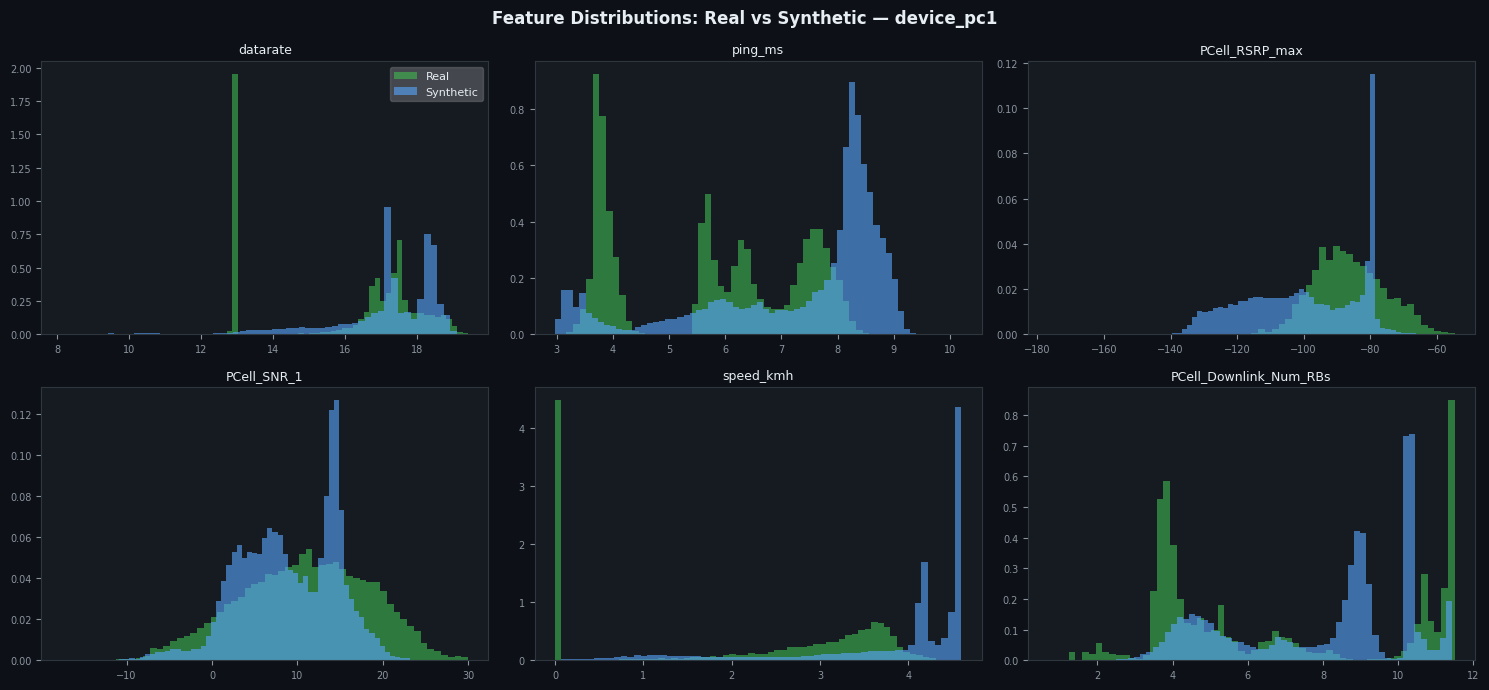

KS Test  (p > 0.05 = distributions are similar)
  Feature                              KS stat     p-value  Result
  --------------------------------------------------------------
  PCell_RSRP_max                        0.4022      0.0000  differs  ✗
  PCell_RSRQ_max                        0.4618      0.0000  differs  ✗
  PCell_RSSI_max                        0.1953      0.0000  differs  ✗
  PCell_SNR_1                           0.1951      0.0000  differs  ✗
  PCell_SNR_2                           0.1591      0.0000  differs  ✗
  PCell_Downlink_Num_RBs                0.3096      0.0000  differs  ✗
  PCell_Downlink_TB_Size                0.3738      0.0000  differs  ✗
  PCell_Downlink_Average_MCS            0.1474      0.0000  differs  ✗
  PCell_Uplink_Num_RBs                  0.4353      0.0000  differs  ✗
  PCell_Uplink_TB_Size                  0.3110      0.0000  differs  ✗
  PCell_Uplink_Tx_Power_(dBm)           0.3140      0.0000  differs  ✗
  PCell_Downlink_frequency             

In [17]:
# Pick one device for validation
VAL_DEVICE = 1
tl = device_timelines[VAL_DEVICE]

real_rows = tl[tl["source"] == "real"]
syn_rows  = tl[tl["source"] == "synthetic"]

CHECK_FEATS = ["datarate", "ping_ms", "PCell_RSRP_max",
               "PCell_SNR_1", "speed_kmh", "PCell_Downlink_Num_RBs"]

# ── 1. Distribution plots + KS test ──────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 7), facecolor="#0d1117")
for i, feat in enumerate(CHECK_FEATS):
    ax = axes[i//3][i%3]
    ax.set_facecolor("#161b22")
    ax.hist(real_rows[feat].values, bins=60, color="#3fb950",
            alpha=0.6, density=True, label="Real")
    ax.hist(syn_rows[feat].values,  bins=60, color="#58a6ff",
            alpha=0.6, density=True, label="Synthetic")
    ax.set_title(feat, color="#e6edf3", fontsize=9)
    ax.tick_params(colors="#8b949e", labelsize=7)
    for sp in ax.spines.values(): sp.set_edgecolor("#30363d")
    if i == 0: ax.legend(framealpha=0.2, labelcolor="#e6edf3", fontsize=8)

fig.suptitle(f"Feature Distributions: Real vs Synthetic — device_pc{VAL_DEVICE}",
             color="#e6edf3", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

print("KS Test  (p > 0.05 = distributions are similar)")
print(f"  {'Feature':<35} {'KS stat':>8}  {'p-value':>10}  Result")
print("  " + "-" * 62)
for feat in TARGET_FEATURES:
    if feat in real_rows.columns:
        ks, p = sp_stats.ks_2samp(real_rows[feat].dropna().values,
                                   syn_rows[feat].dropna().values)
        result = "similar ✓" if p > 0.05 else "differs  ✗"
        print(f"  {feat:<35} {ks:>8.4f}  {p:>10.4f}  {result}")

In [19]:
# ── 3. TSTR — Train on Synthetic, Test on Real ────────────────────────────
# Predict datarate from signal features using a simple linear model
# If R² on real test data is reasonable, synthetic data is useful

X_FEATS  = ["PCell_RSRP_max", "PCell_SNR_1", "PCell_Uplink_Tx_Power_(dBm)"]
Y_FEAT   = "datarate"

# Filter to rows that have all needed features
real_clean = real_rows[X_FEATS + [Y_FEAT]].dropna()
syn_clean  = syn_rows[ X_FEATS + [Y_FEAT]].dropna()

if len(syn_clean) > 10 and len(real_clean) > 10:
    # Train on synthetic
    model_syn = Ridge()
    model_syn.fit(syn_clean[X_FEATS].values, syn_clean[Y_FEAT].values)
    pred_syn  = model_syn.predict(real_clean[X_FEATS].values)
    r2_syn    = r2_score(real_clean[Y_FEAT].values, pred_syn)

    # Train on real (baseline)
    from sklearn.model_selection import cross_val_score
    model_real = Ridge()
    scores     = cross_val_score(model_real, real_clean[X_FEATS].values,
                                  real_clean[Y_FEAT].values, cv=5, scoring="r2")
    r2_real    = scores.mean()

    print("TSTR — Train on Synthetic, Test on Real")
    print(f"  Predict '{Y_FEAT}' from {X_FEATS}")
    print(f"  R² trained on SYNTHETIC, tested on real : {r2_syn:.4f}")
    print(f"  R² trained on REAL     (5-fold CV)      : {r2_real:.4f}")
    ratio = r2_syn / r2_real if r2_real > 0 else 0
    print(f"  Ratio (TSTR / real-baseline)            : {ratio:.2f}")
    print()
    if ratio >= 0.7:
        print("  ✓ Synthetic data retains enough structure for downstream tasks")
    elif ratio >= 0.4:
        print("  ~ Synthetic data partially useful — more training may help")
    else:
        print("  ✗ Synthetic data not yet useful — check training convergence")
else:
    print("Not enough data for TSTR — run more epochs first")

TSTR — Train on Synthetic, Test on Real
  Predict 'datarate' from ['PCell_RSRP_max', 'PCell_SNR_1', 'PCell_Uplink_Tx_Power_(dBm)']
  R² trained on SYNTHETIC, tested on real : -0.2622
  R² trained on REAL     (5-fold CV)      : -3.7343
  Ratio (TSTR / real-baseline)            : 0.00

  ✗ Synthetic data not yet useful — check training convergence


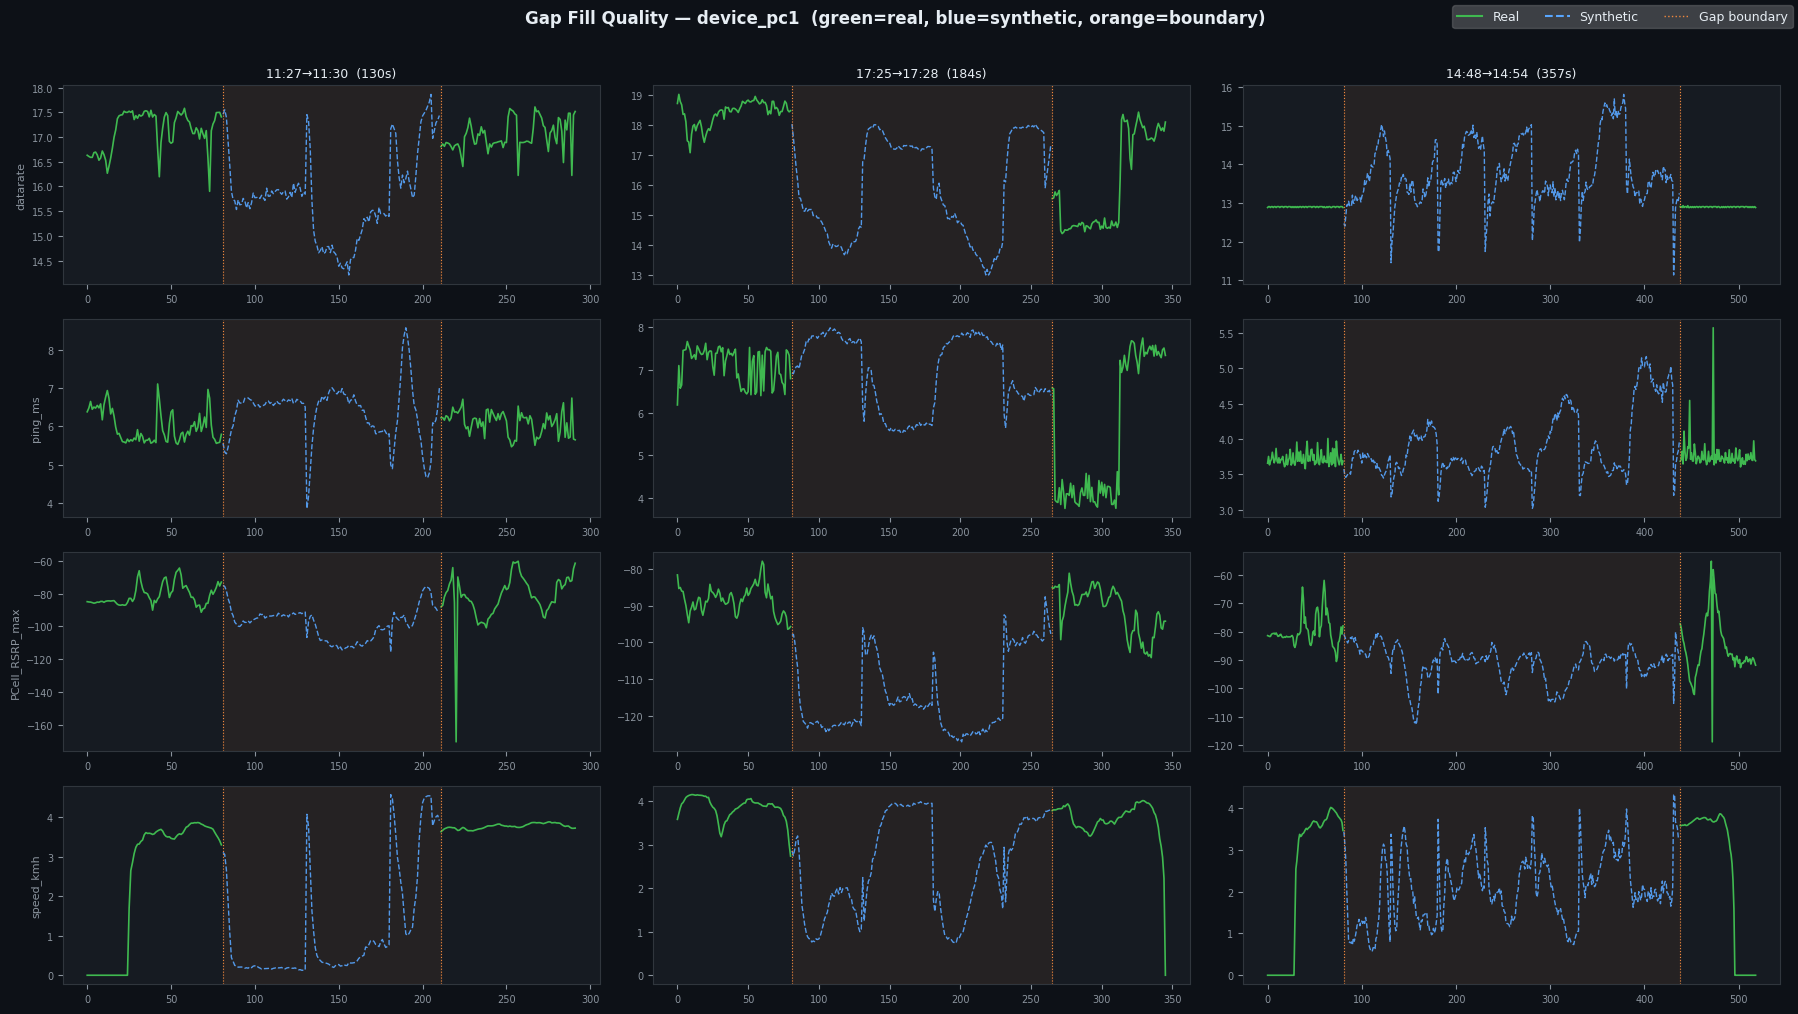

In [20]:
# Show real → synthetic fill → real for the 3 smallest gaps
SHOW_FEATS   = ["datarate", "ping_ms", "PCell_RSRP_max", "speed_kmh"]
SHOW_CONTEXT = 80   # real rows to show on each side of each gap

small_gaps = sorted(
    [(i, v) for i, v in filled.items() if v["device"] == VAL_DEVICE],
    key=lambda x: x[1]["scaled"].shape[0]
)[:3]

if not small_gaps:
    print(f"No filled gaps for device_pc{VAL_DEVICE} — try a different VAL_DEVICE")
else:
    tl = device_timelines[VAL_DEVICE]
    fig, axes = plt.subplots(len(SHOW_FEATS), len(small_gaps),
                             figsize=(6 * len(small_gaps), 2.5 * len(SHOW_FEATS)),
                             facecolor="#0d1117")
    if len(small_gaps) == 1:
        axes = [[ax] for ax in axes]

    for col, (_, ginfo) in enumerate(small_gaps):
        t0, t1 = ginfo["gap_start"], ginfo["gap_end"]
        window = tl[
            (tl["timestamp"] >= t0 - pd.Timedelta(seconds=SHOW_CONTEXT)) &
            (tl["timestamp"] <= t1 + pd.Timedelta(seconds=SHOW_CONTEXT))
        ]
        pre  = window[(window["source"]=="real") & (window["timestamp"] <= t0)]
        syn  = window[ window["source"]=="synthetic"]
        post = window[(window["source"]=="real") & (window["timestamp"] >= t1)]

        for row, feat in enumerate(SHOW_FEATS):
            ax = axes[row][col]
            ax.set_facecolor("#161b22")
            n_pre = len(pre)
            ax.plot(range(n_pre),
                    pre[feat].values,  color="#3fb950", lw=1.2, label="Real")
            ax.plot(range(n_pre, n_pre + len(syn)),
                    syn[feat].values,  color="#58a6ff", lw=1.0, ls="--",
                    alpha=0.9, label="Synthetic")
            ax.plot(range(n_pre + len(syn), n_pre + len(syn) + len(post)),
                    post[feat].values, color="#3fb950", lw=1.2)
            ax.axvspan(n_pre, n_pre + len(syn), color="#f0883e", alpha=0.07)
            ax.axvline(n_pre,            color="#f0883e", lw=0.8, ls=":")
            ax.axvline(n_pre+len(syn),   color="#f0883e", lw=0.8, ls=":")

            if col == 0: ax.set_ylabel(feat, color="#8b949e", fontsize=8)
            if row == 0:
                ax.set_title(
                    f"{str(t0)[11:16]}→{str(t1)[11:16]}  ({ginfo['scaled'].shape[0]}s)",
                    color="#e6edf3", fontsize=9)
            ax.tick_params(colors="#8b949e", labelsize=7)
            for sp in ax.spines.values(): sp.set_edgecolor("#30363d")

    handles = [plt.Line2D([0],[0], color="#3fb950", lw=1.5, label="Real"),
               plt.Line2D([0],[0], color="#58a6ff", lw=1.5, ls="--", label="Synthetic"),
               plt.Line2D([0],[0], color="#f0883e", lw=1.0, ls=":", label="Gap boundary")]
    fig.legend(handles=handles, loc="upper right", framealpha=0.2,
               labelcolor="#e6edf3", fontsize=9, ncol=3)
    fig.suptitle(f"Gap Fill Quality — device_pc{VAL_DEVICE}  "
                 f"(green=real, blue=synthetic, orange=boundary)",
                 color="#e6edf3", fontsize=12, fontweight="bold", y=1.01)
    plt.tight_layout(); plt.show()

In [21]:
# Save model weights
torch.save(Enc.state_dict(), os.path.join(S.save_dir, "encoder.pt"))
torch.save(G.state_dict(),   os.path.join(S.save_dir, "generator.pt"))
torch.save(D.state_dict(),   os.path.join(S.save_dir, "discriminator.pt"))

# Save filled timelines
for d, tl in device_timelines.items():
    tl.to_pickle(os.path.join(S.save_dir, f"timeline_device_pc{d}.pkl"))
    tl.to_csv(   os.path.join(S.save_dir, f"timeline_device_pc{d}.csv"), index=False)

# Save combined
df_combined.to_pickle(os.path.join(S.save_dir, "timeline_all_devices.pkl"))
df_combined.to_csv(   os.path.join(S.save_dir, "timeline_all_devices.csv"), index=False)

# Save settings
with open(os.path.join(S.save_dir, "settings.json"), "w") as f:
    json.dump(asdict(S), f, indent=2, default=str)

n_real = (df_combined["source"] == "real").sum()
n_syn  = (df_combined["source"] == "synthetic").sum()
print(f"Saved to '{S.save_dir}/'")
print(f"  Real rows      : {n_real:,}")
print(f"  Synthetic rows : {n_syn:,}")
print(f"  Total          : {len(df_combined):,}")

Saved to 'outputs_gan/'
  Real rows      : 204,942
  Synthetic rows : 100,744
  Total          : 305,686
